In [1]:
# ================================================
# IT Support Ticket Classifier
# Built by: [Your Name]
# Dataset: IT Service Ticket Classification (Kaggle)
# ================================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
print("All libraries loaded successfully!")

All libraries loaded successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Load the dataset
df = pd.read_csv("all_tickets_processed_improved_v3.csv")
print("Dataset shape:", df.shape)
print("\nCategory distribution:")
print(df["Topic_group"].value_counts())

Dataset shape: (47837, 2)

Category distribution:
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


In [3]:
def clean_text(text):
    """
    Cleans raw ticket text:
    - Lowercases all words
    - Removes punctuation and numbers
    - Removes common stopwords (the, is, a...)
    """
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["cleaned"] = df["Document"].apply(clean_text)
print("Text cleaning complete!")
print("\nBefore:", df["Document"][0][:100])
print("After: ", df["cleaned"][0][:100])

Text cleaning complete!

Before: connection with icon icon dear please setup icon per icon engineers please let other details needed 
After:  connection icon icon dear please setup icon per icon engineers please let details needed thanks lead


In [4]:
# Convert category names to numbers for the model
le = LabelEncoder()
df["label"] = le.fit_transform(df["Topic_group"])
print("Label encoding:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# Convert text to TF-IDF numerical vectors
# max_features=5000 keeps the 5000 most important words
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df["cleaned"])
y = df["label"]
print("\nTF-IDF matrix shape:", X.shape)

Label encoding:
{'Access': np.int64(0), 'Administrative rights': np.int64(1), 'HR Support': np.int64(2), 'Hardware': np.int64(3), 'Internal Project': np.int64(4), 'Miscellaneous': np.int64(5), 'Purchase': np.int64(6), 'Storage': np.int64(7)}

TF-IDF matrix shape: (47837, 5000)


In [5]:
# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Logistic Regression classifier
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Evaluate on unseen test data
preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)
print(f"Model Accuracy: {acc * 100:.2f}%\n")
print(classification_report(y_test, preds, target_names=le.classes_))

Model Accuracy: 85.11%

                       precision    recall  f1-score   support

               Access       0.92      0.87      0.90      1455
Administrative rights       0.86      0.67      0.76       342
           HR Support       0.85      0.84      0.84      2107
             Hardware       0.80      0.89      0.84      2760
     Internal Project       0.93      0.80      0.86       451
        Miscellaneous       0.81      0.83      0.82      1400
             Purchase       0.97      0.88      0.92       497
              Storage       0.93      0.85      0.89       556

             accuracy                           0.85      9568
            macro avg       0.88      0.83      0.85      9568
         weighted avg       0.86      0.85      0.85      9568



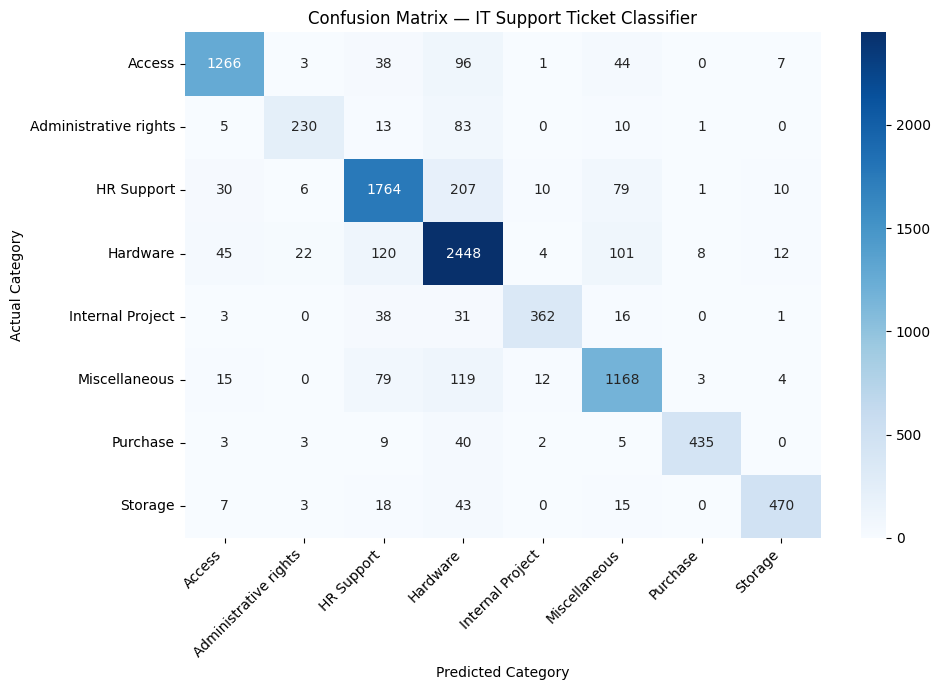

In [6]:
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix — IT Support Ticket Classifier")
plt.ylabel("Actual Category")
plt.xlabel("Predicted Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

In [7]:
def assign_priority(text):
    """
    Rule-based priority assignment:
    - Critical: system down, broken, urgent
    - High:     password, access blocked, storage full
    - Low:      general requests, new equipment
    - Medium:   everything else
    """
    text = text.lower()
    if any(w in text for w in ["broken","not working","down","crashed",
                                "urgent","emergency","wont turn on"]):
        return "Critical"
    elif any(w in text for w in ["password","expired","locked","reset",
                                  "blocked","full","cannot receive"]):
        return "High"
    elif any(w in text for w in ["request","please","meeting","new",
                                  "setup","install","would like"]):
        return "Low"
    else:
        return "Medium"

def classify_ticket(text):
    """
    Full pipeline: takes raw ticket text,
    returns category and priority
    """
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)
    category = le.inverse_transform(prediction)[0]
    priority = assign_priority(text)
    print(f"Ticket:   {text}")
    print(f"Category: {category}")
    print(f"Priority: {priority}")
    print("---")

# Demo
classify_ticket("my laptop screen is broken and wont turn on")
classify_ticket("please reset my password it has expired")
classify_ticket("mailbox is full cannot receive any emails")
classify_ticket("urgent server is down nobody can work")
classify_ticket("request for new keyboard and mouse")

Ticket:   my laptop screen is broken and wont turn on
Category: Hardware
Priority: Critical
---
Ticket:   please reset my password it has expired
Category: Access
Priority: High
---
Ticket:   mailbox is full cannot receive any emails
Category: Storage
Priority: High
---
Ticket:   urgent server is down nobody can work
Category: Hardware
Priority: Critical
---
Ticket:   request for new keyboard and mouse
Category: Hardware
Priority: Low
---
